# Plot dos casos do artigo (2x2)

Este notebook carrega os resultados gerados por `run_article_all_cases_simple.py` e, para **cada caso**, plota uma figura com **4 painéis em 2 linhas × 2 colunas**:

1. **não-classicalidade**;
2. **acoplamento** $g(t)$;
3. **valor esperado** $\langle Z 
angle$;
4. **valor esperado** $\langle N 
angle$.

Mudanças desta versão:

- **sem heatmap/superfície**;
- **sem variância**;
- inclusão do **acoplamento** junto com os demais gráficos.


In [1]:
import os
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (12, 8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

## Configuração

Se quiser, altere manualmente `ROOT`. Se deixar `None`, o notebook pega automaticamente a pasta mais recente em `results/article_all_cases/article_all_cases*`.


In [2]:
def latest_root(base="results/article_all_cases"):
    folders = sorted(glob.glob(os.path.join(base, "article_all_cases*")))
    if not folders:
        raise FileNotFoundError(
            "Não encontrei resultados. Rode primeiro: python run_article_all_cases_simple.py"
        )
    return folders[-1]

ROOT = None
if ROOT is None:
    ROOT = latest_root()

ROOT

'results/article_all_cases/article_all_cases2'

## Funções auxiliares

In [3]:
def case_dir(case_id):
    return os.path.join(ROOT, case_id)


def load_case(case_id):
    folder = case_dir(case_id)
    with open(os.path.join(folder, "case_metadata.json"), "r", encoding="utf-8") as f:
        meta = json.load(f)

    return {
        "folder": folder,
        "meta": meta,
        "t": np.load(os.path.join(folder, "t.npy")),
        "const_aberto": np.load(os.path.join(folder, "const_aberto.npy")),
        "var_aberto": np.load(os.path.join(folder, "var_aberto.npy")),
        "scan": pd.read_csv(os.path.join(folder, "scan_points_used.csv")),
        "summary": pd.read_csv(os.path.join(folder, "summary.csv")),
    }


def load_observables(case_id, label):
    path = os.path.join(case_dir(case_id), f"{label}_observables.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Não achei: {path}")
    return pd.read_csv(path)


def safe_log_limits(arrays, floor=1e-12):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        vals.extend(arr[np.isfinite(arr) & (arr > 0)].tolist())
    if not vals:
        return floor, 1.0
    return max(floor, min(vals) * 0.7), max(vals) * 1.3


def labels_for_case(data):
    labels = [("const_aberto", "const. aberto", data["const_aberto"])]
    for i, row in data["scan"].iterrows():
        label = f"var_aberto_{row['label']}"
        pretty = f"{row['label']} = {row['display_value']:.4g}"
        labels.append((label, pretty, data["var_aberto"][i]))
    return labels


def use_log_for_metric(resource):
    return resource in {"coherence", "entanglement"}


def plot_case_2x2(case_id, save=False):
    data = load_case(case_id)
    meta = data["meta"]
    t = data["t"]
    resource = meta["resource"]
    metric_label = meta.get("metric_label", "non-classicality")

    curves = labels_for_case(data)

    fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), sharex="col", constrained_layout=True)

    ax_metric = axes[0, 0]
    ax_g = axes[0, 1]
    ax_z = axes[1, 0]
    ax_n = axes[1, 1]

    metric_arrays = []
    legend_handles = []
    legend_labels = []

    for label, pretty, y_metric in curves:
        df = load_observables(case_id, label)
        style = {"lw": 2.2, "linestyle": "--"} if "const" in pretty else {"lw": 1.9}

        line_metric, = ax_metric.plot(t, y_metric, label=pretty, **style)
        ax_g.plot(df["time"], df["g_t"], **style)
        ax_z.plot(df["time"], df["expect_Z"], **style)
        ax_n.plot(df["time"], df["expect_N"], **style)

        metric_arrays.append(y_metric)
        legend_handles.append(line_metric)
        legend_labels.append(pretty)

    if use_log_for_metric(resource):
        ax_metric.set_yscale("log")
        ax_metric.set_ylim(*safe_log_limits(metric_arrays))

    ax_metric.set_ylabel(metric_label)
    ax_metric.set_title("Não-classicalidade")

    ax_g.set_ylabel(r"$g(t)$")
    ax_g.set_title("Acoplamento")

    ax_z.set_ylabel(r"$\langle Z \rangle$")
    ax_z.set_title(r"Valor esperado de $Z$")
    ax_z.set_xlabel("t")

    ax_n.set_ylabel(r"$\langle N \rangle$")
    ax_n.set_title(r"Valor esperado de $N$")
    ax_n.set_xlabel("t")

    fig.suptitle(
        f"{meta['article_fig']} | {resource} | {meta['coupling']} | {meta['scan_display_name']}",
        fontsize=13,
    )
    fig.legend(legend_handles, legend_labels, loc="upper center", ncol=4, fontsize=9)

    if save:
        out = os.path.join(data["folder"], f"plot_2x2_nonclassicality_g_Z_N_{case_id}.png")
        fig.savefig(out, dpi=220, bbox_inches="tight")
        print("salvo:", out)

    plt.show()


def show_summary(case_id):
    return load_case(case_id)["summary"]

case_map = pd.read_csv(os.path.join(ROOT, "case_map.csv"))
case_map

,case_id,article_fig,resource,state_kind,coupling,scan_name,scan_display_name,fixed_args,tmax,metric_label,case_dir
0,fig1_coherence_gauss_epsilon,Fig. 1,coherence,coherence,gauss,epsilon,zeta,"{""T"": 25.0, ""sigma"": -1.0}",50.0,C_q(t),fig1_coherence_gauss_epsilon
1,fig2_coherence_gauss_T,Fig. 2,coherence,coherence,gauss,T,T,"{""epsilon"": 8.0, ""sigma"": -1.0}",50.0,C_q(t),fig2_coherence_gauss_T
2,fig3_coherence_cos_omega,Fig. 3,coherence,coherence,cos,w,omega_units,"{""phi"": 0.0}",50.0,C_q(t),fig3_coherence_cos_omega
3,magic_gauss_epsilon,Magic / Eq. 9 + Fig. 1 parameters,magic,magic,gauss,epsilon,zeta,"{""T"": 25.0, ""sigma"": -1.0}",50.0,M_2(t),magic_gauss_epsilon
4,magic_gauss_T,Magic / Eq. 9 + Fig. 2 parameters,magic,magic,gauss,T,T,"{""epsilon"": 8.0, ""sigma"": -1.0}",50.0,M_2(t),magic_gauss_T
5,magic_cos_omega,Magic / Eq. 9 + Fig. 3 parameters,magic,magic,cos,w,omega_units,"{""phi"": 0.0}",50.0,M_2(t),magic_cos_omega
6,fig4_wigner_gauss_epsilon,Fig. 4,wigner,wigner,gauss,epsilon,zeta,"{""T"": 7.5, ""sigma"": -1.0}",15.0,N_W(t),fig4_wigner_gauss_epsilon
7,fig5_wigner_gauss_T,Fig. 5,wigner,wigner,gauss,T,T,"{""epsilon"": 2.4, ""sigma"": -1.0}",15.0,N_W(t),fig5_wigner_gauss_T
8,fig6_wigner_cos_omega,Fig. 6,wigner,wigner,cos,w,omega,"{""phi"": 0.0}",15.0,N_W(t),fig6_wigner_cos_omega
9,fig7_entanglement_gauss_epsilon,Fig. 7,entanglement,entanglement,gauss,epsilon,zeta,"{""T"": 25.0, ""sigma"": -1.0}",50.0,E_N(t),fig7_entanglement_gauss_epsilon


## Plotar um caso específico

In [4]:
# Exemplo: escolha um case_id da tabela acima
case_id = case_map.iloc[0]["case_id"]
case_id

'fig1_coherence_gauss_epsilon'

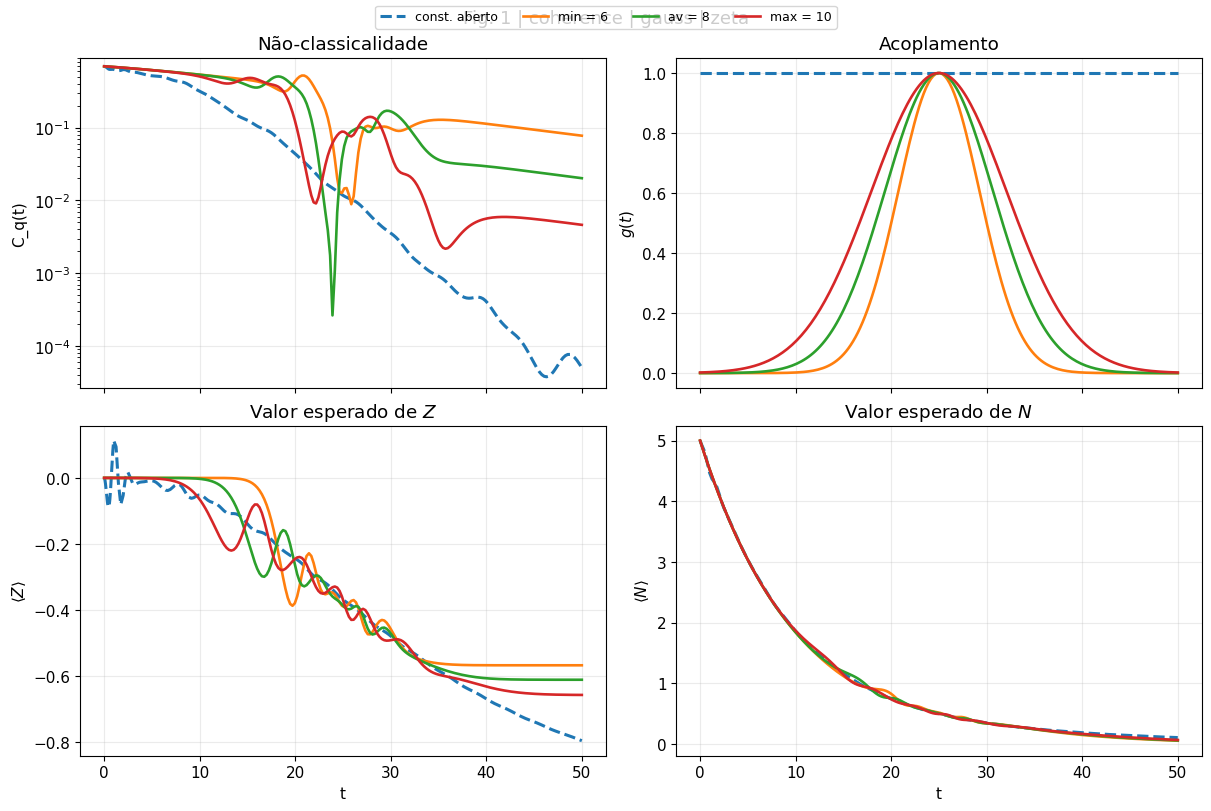

In [5]:
plot_case_2x2(case_id, save=False)

## Tabela-resumo do caso

In [6]:
show_summary(case_id)

,label,case_id,scan_name,scan_value,display_value,metric_initial,metric_max,metric_mean,metric_final,time_at_max
0,const_aberto,fig1_coherence_gauss_epsilon,const,NaN,NaN,0.693147,0.693147,0.299685,0.000051,0.0
1,var_aberto_min,fig1_coherence_gauss_epsilon,epsilon,6.0,6.0,0.693147,0.693147,0.414540,0.077349,0.0
2,var_aberto_av,fig1_coherence_gauss_epsilon,epsilon,8.0,8.0,0.693147,0.693147,0.389954,0.020188,0.0
3,var_aberto_max,fig1_coherence_gauss_epsilon,epsilon,10.0,10.0,0.693147,0.693147,0.369798,0.004624,0.0


## Plotar todos os casos

Se quiser salvar as figuras automaticamente nas respectivas pastas de cada caso, mude `SAVE_ALL = True`.

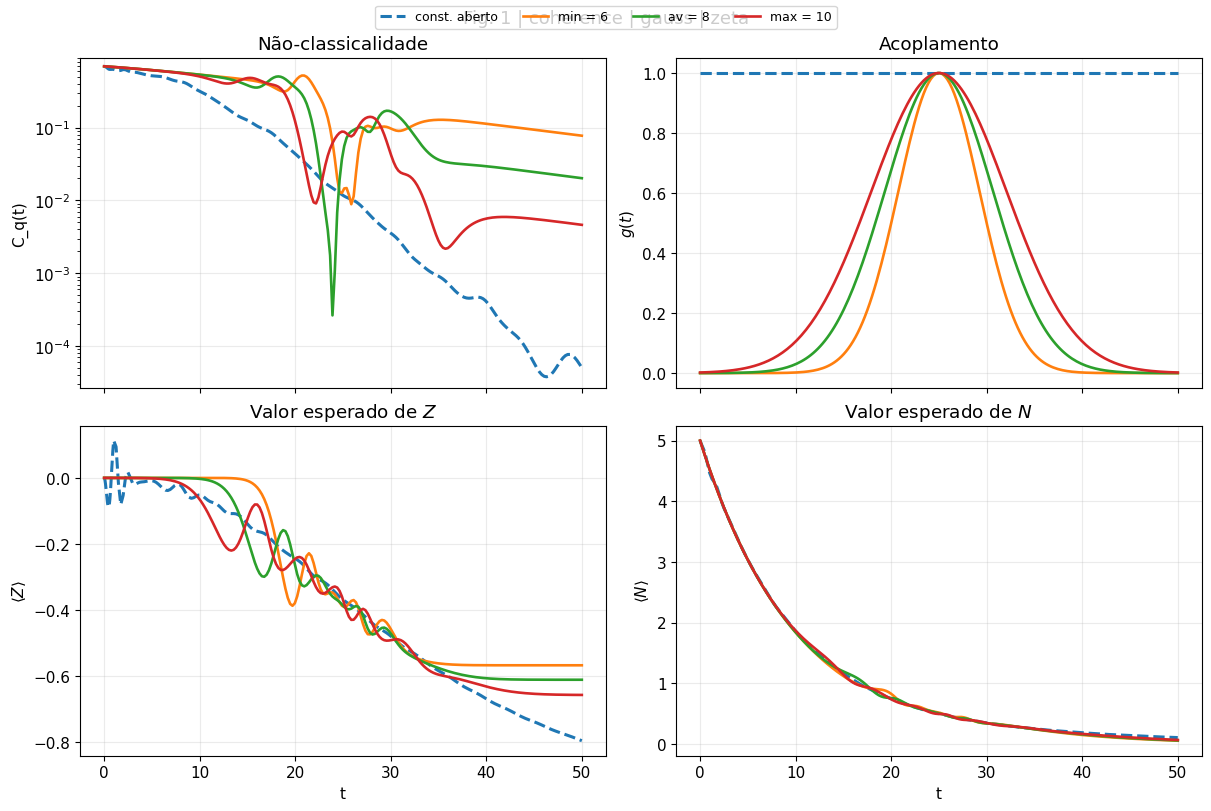

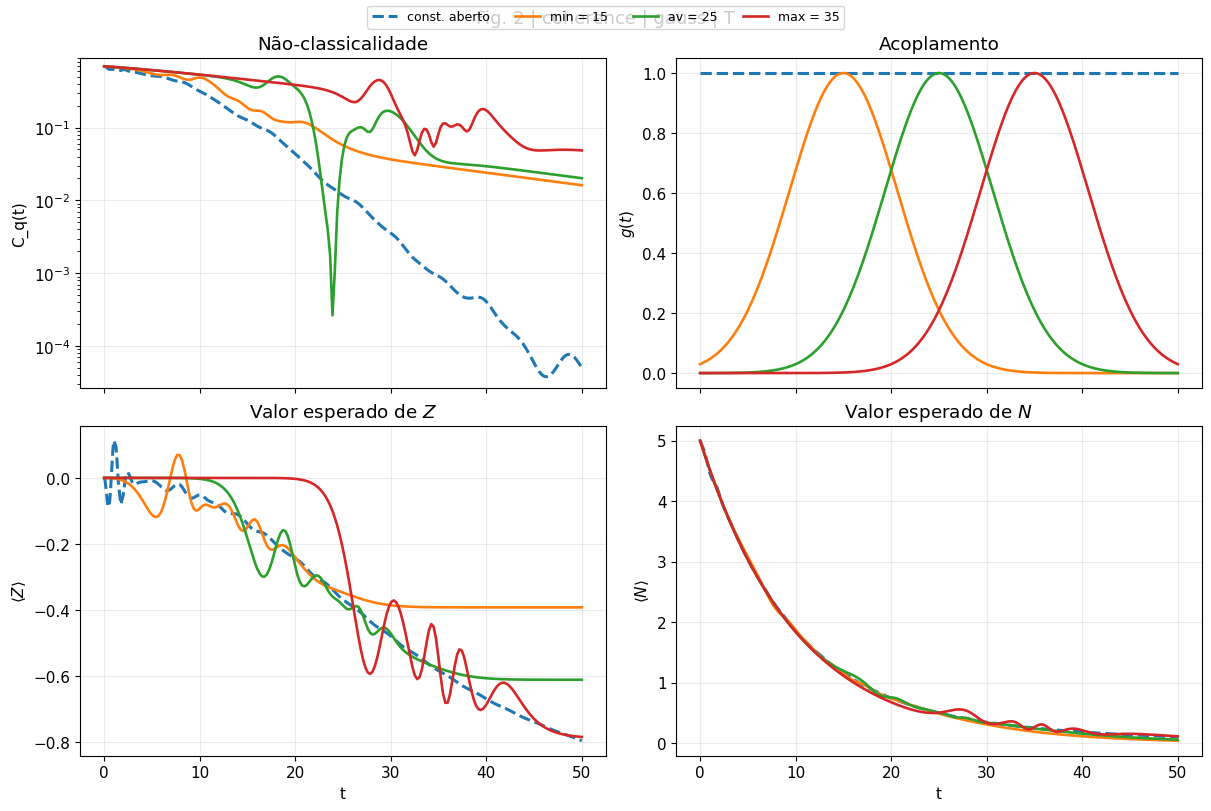

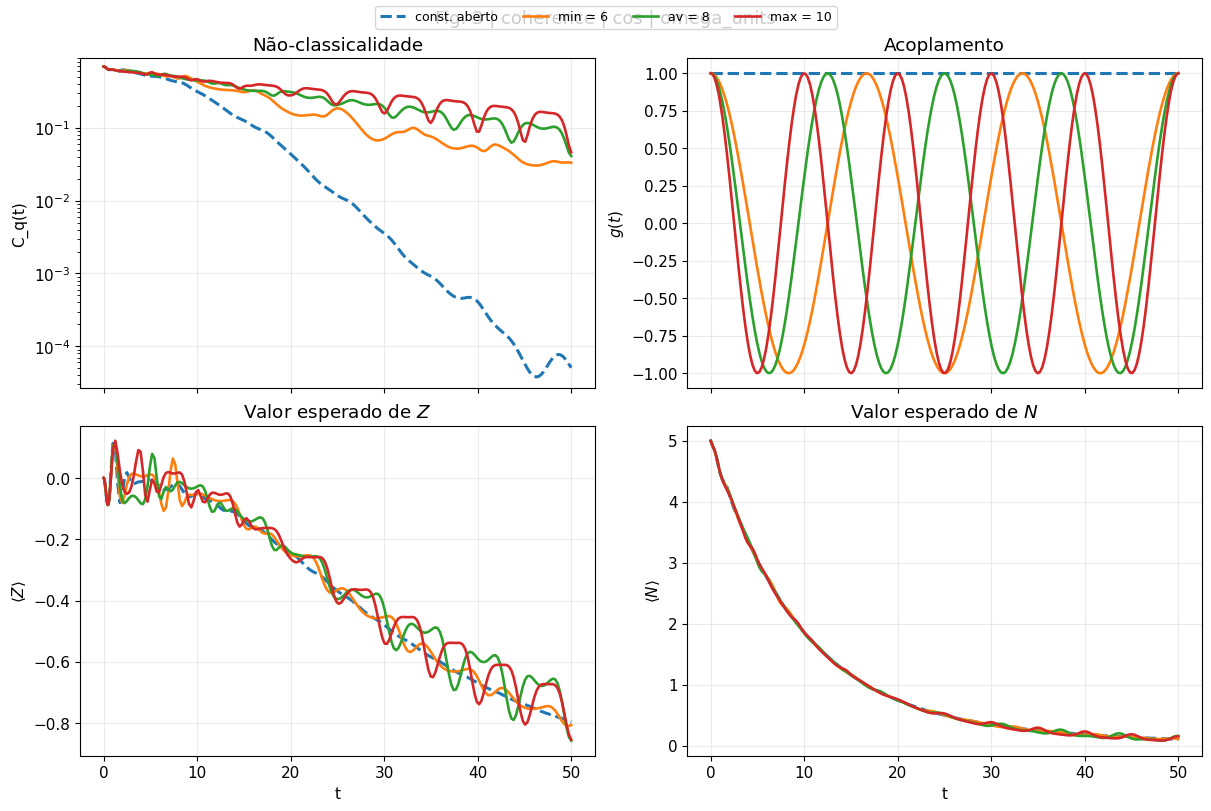

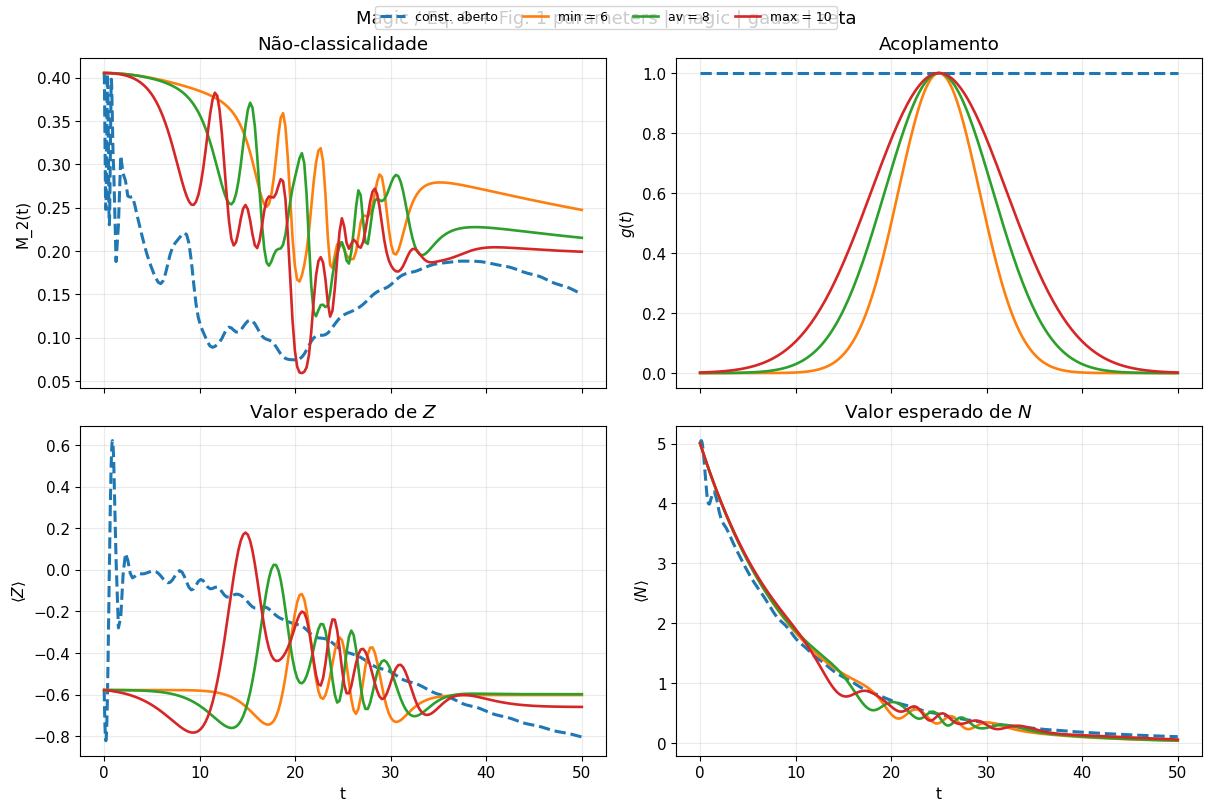

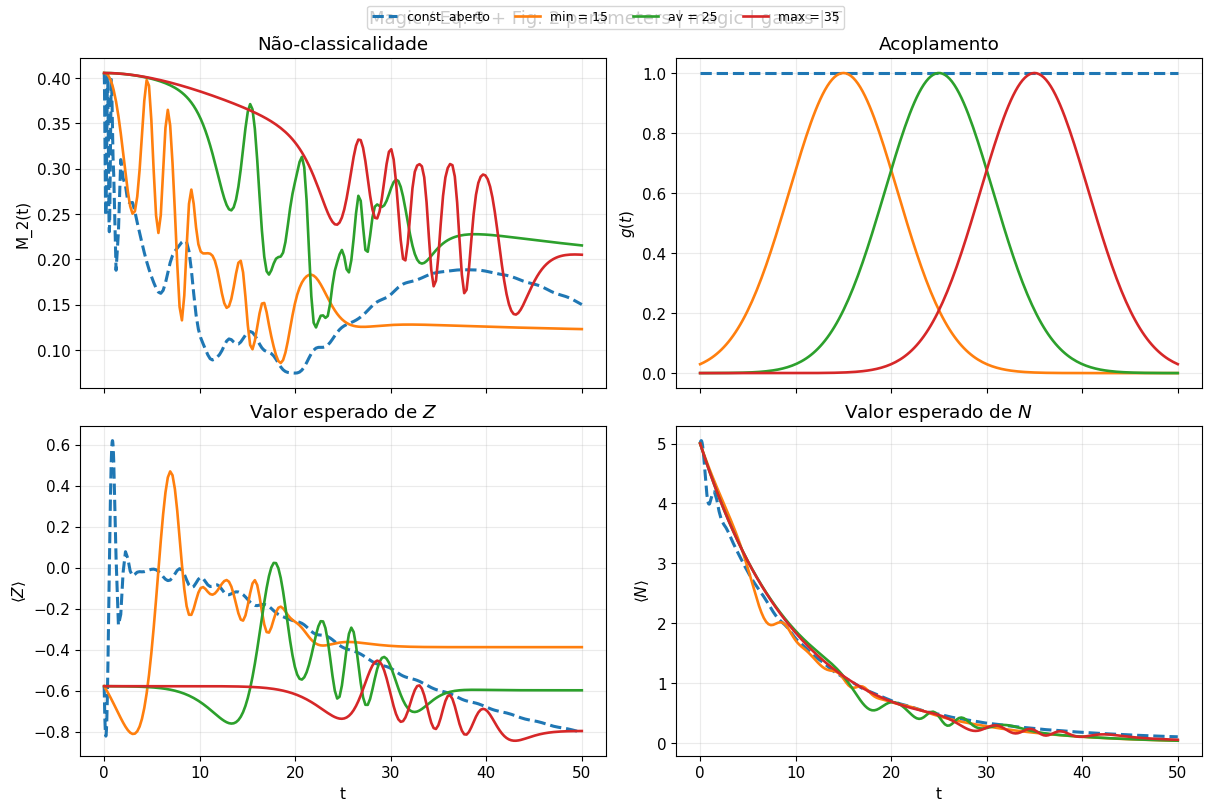

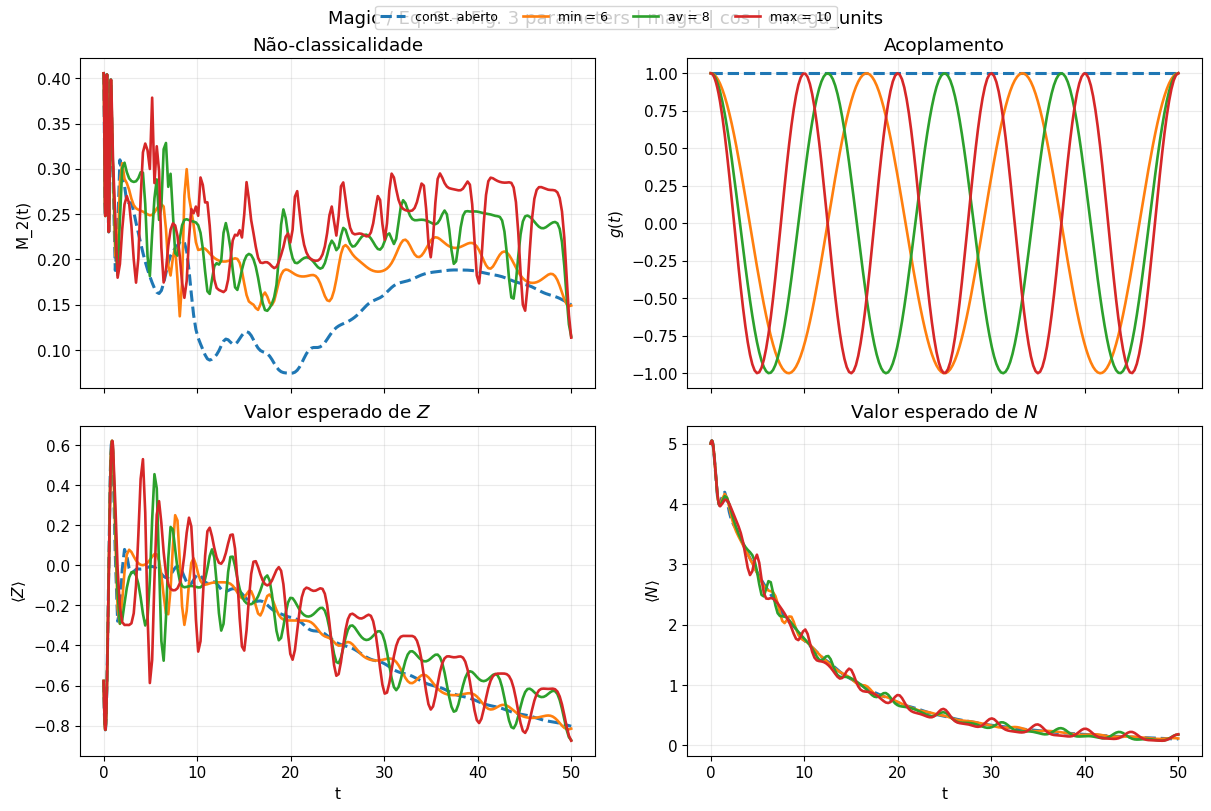

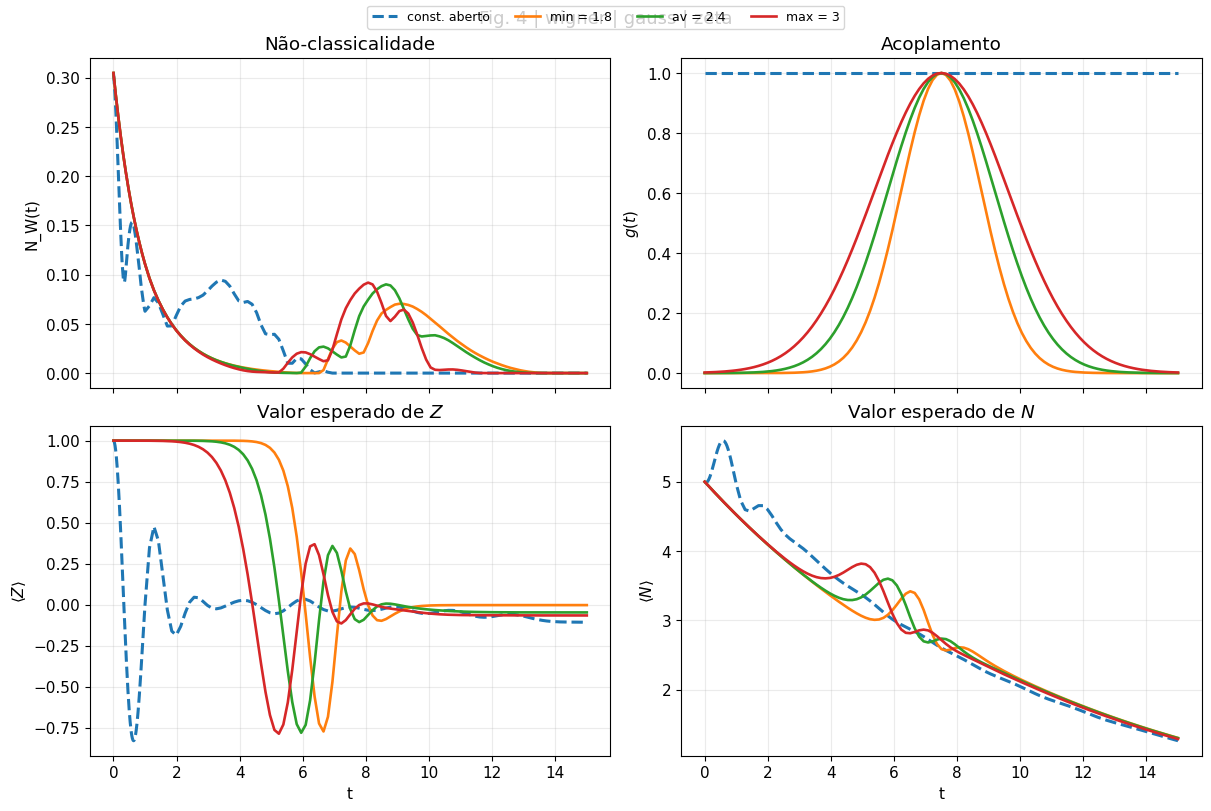

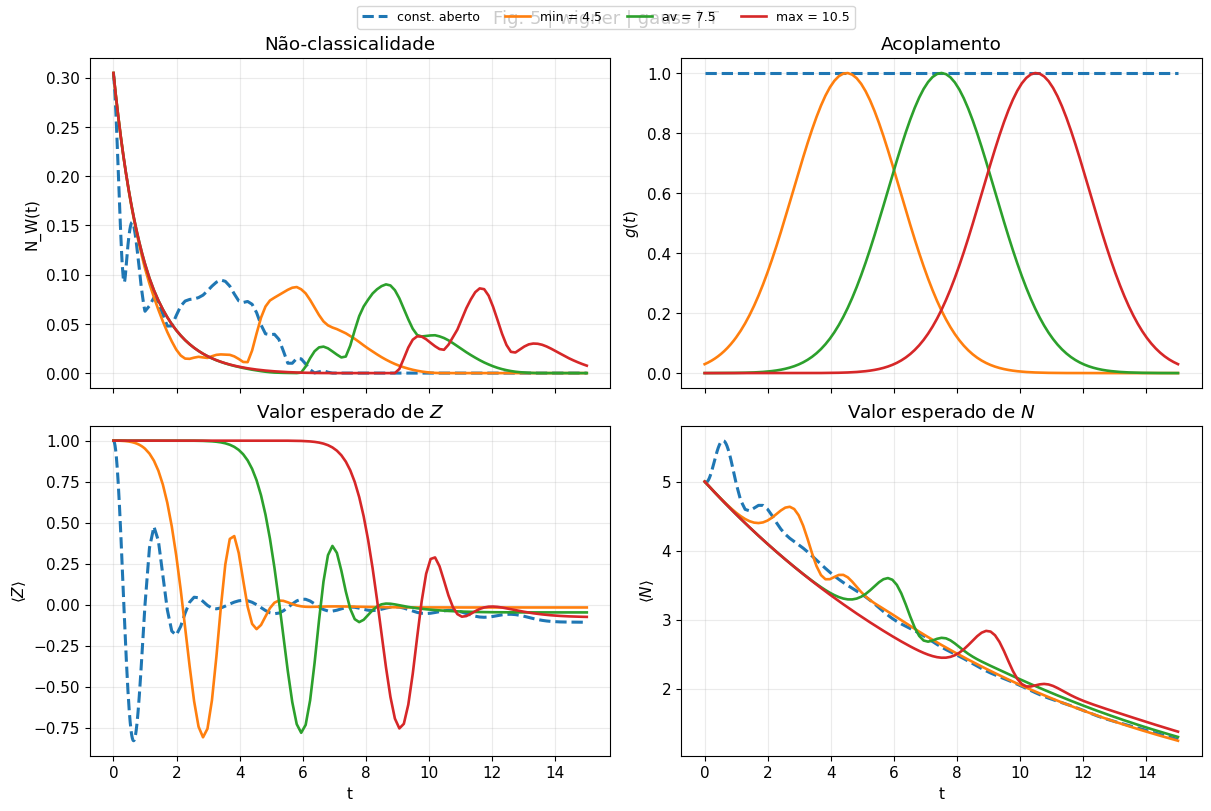

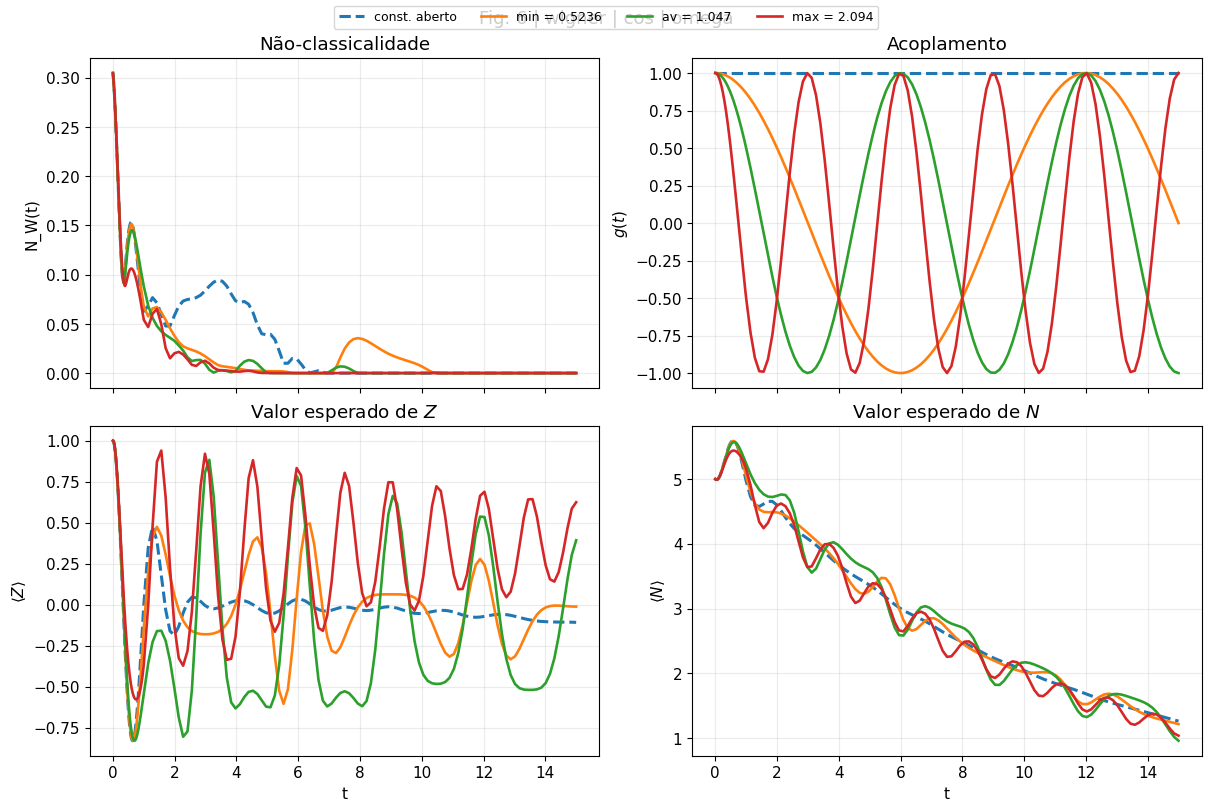

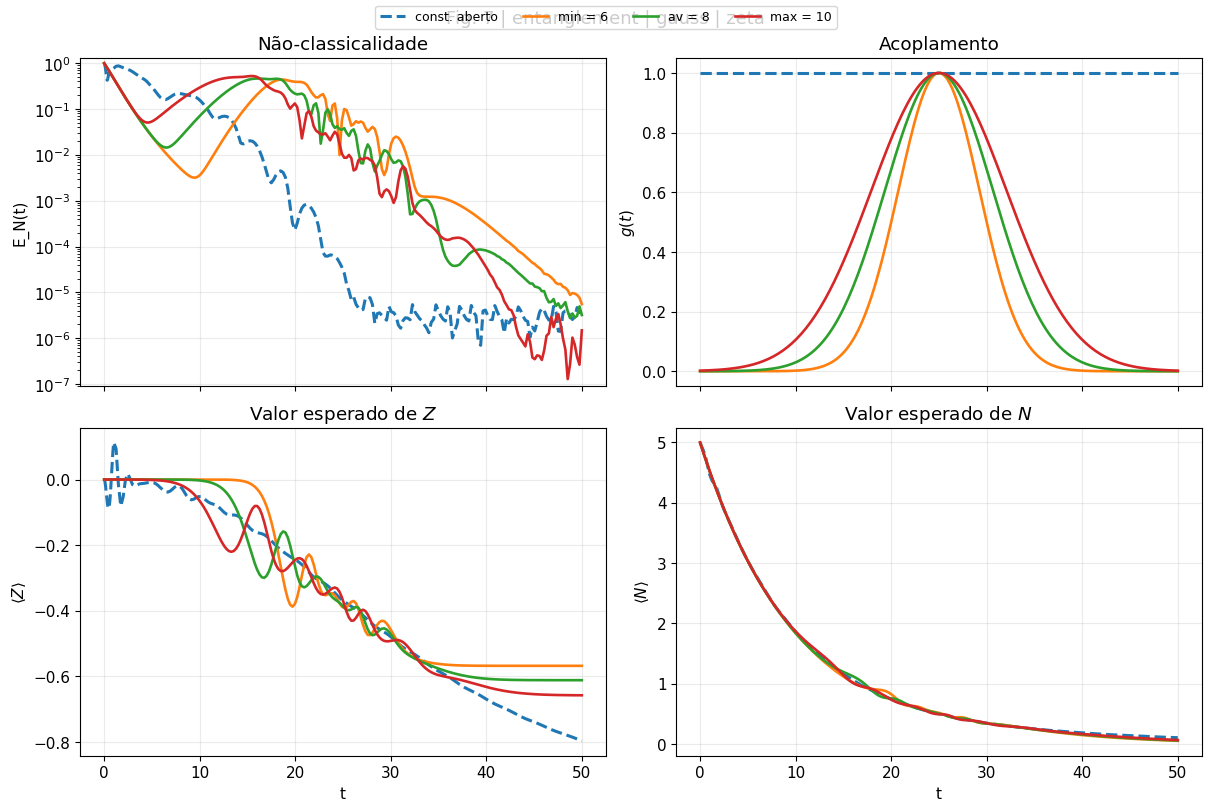

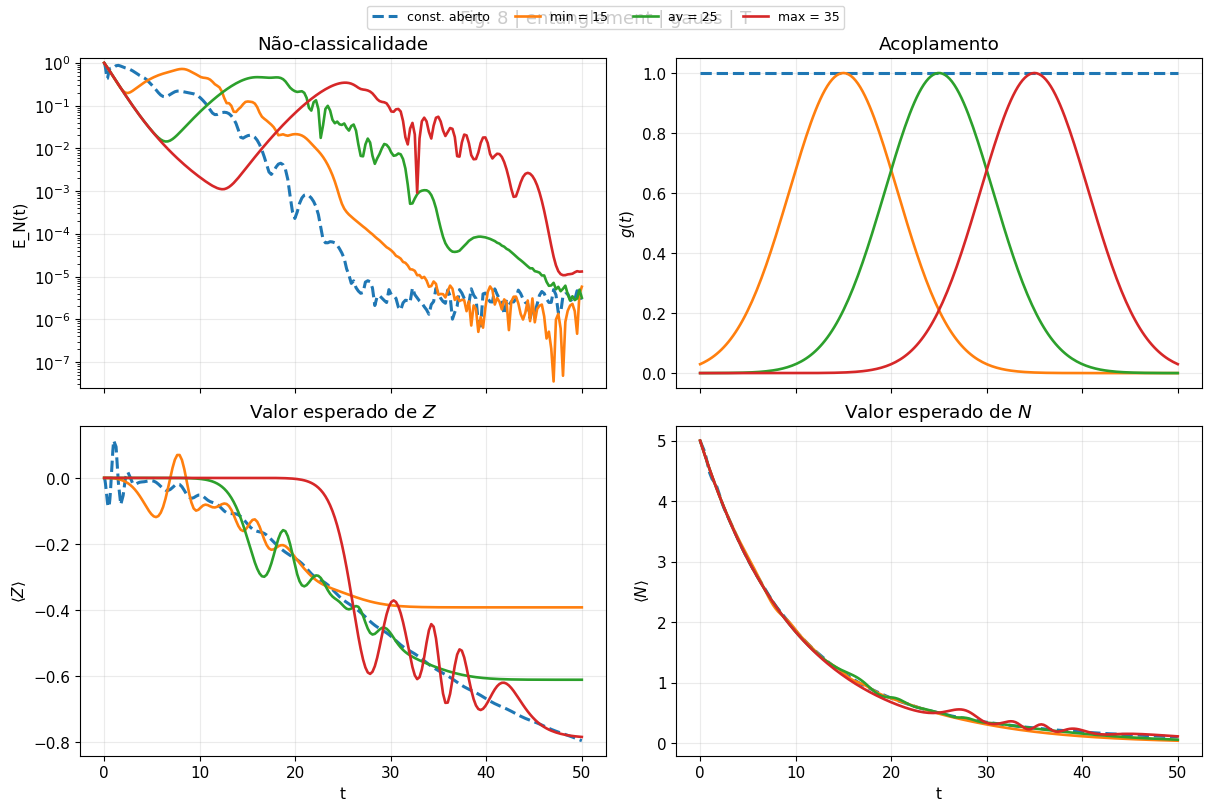

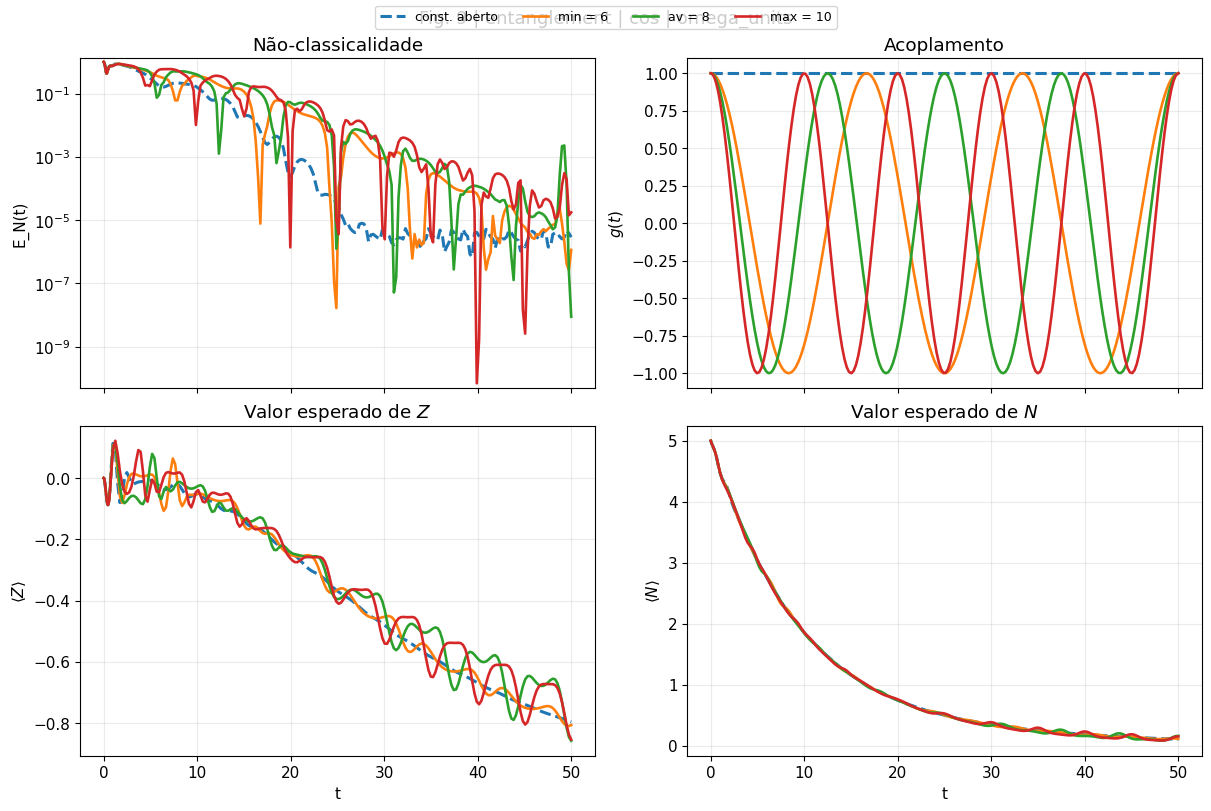

In [7]:
SAVE_ALL = False
for cid in case_map["case_id"].tolist():
    plot_case_2x2(cid, save=SAVE_ALL)